# NeuralDream: EEG to Image Decoding
Mapping 17-channel EEG temporal signals to a 512-d CLIP space for image reconstruction.

**Dataset:** THINGS-EEG2
* Train: 16,540 concepts (Shape: `16540, 4, 17, 100`)
* Test: 200 concepts (Shape: `200, 80, 17, 100`)
* Dimensions: `concepts x reps x channels x timepoints`

In [1]:
# Setup environment (uncomment to install)
!pip install torch torchvision transformers pillow scikit-learn matplotlib tqdm diffusers accelerate

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import math
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPProcessor, CLIPModel

warnings.filterwarnings('ignore')

C:\Users\Hariom soni\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__} | Device: {DEVICE}')

if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.12.0+cpu | Device: cpu


In [16]:

# Setup directories 
BASE_DIR = os.path.expanduser('~/Desktop/eegproject')
RAW_EEG_DIR = os.path.join(BASE_DIR, 'data', 'raw_eeg')
TRAIN_IMG_DIR = os.path.join(BASE_DIR, 'data', 'images', 'train')
TEST_IMG_DIR = os.path.join(BASE_DIR, 'data', 'images', 'test')

CACHE_DIR = os.path.join(BASE_DIR, 'cache')
CKPT_DIR = os.path.join(BASE_DIR, 'checkpoints')
GEN_DIR = os.path.join(BASE_DIR, 'generated')

# Create output dirs if they don't exist
for d in [CACHE_DIR, CKPT_DIR, GEN_DIR]:
    os.makedirs(d, exist_ok=True)

SUBJECTS = [f'sub-{i:02d}' for i in range(1, 11)]

print(f'Base Dir: {BASE_DIR}')
print(f'Subjects: {len(SUBJECTS)} total ({SUBJECTS[0]} ... {SUBJECTS[-1]})')

Base Dir: C:\Users\Hariom soni/Desktop/eegproject
Subjects: 10 total (sub-01 ... sub-10)


In [17]:
# Data dimensions
N_CONCEPTS_TRAIN = 16540
N_CONCEPTS_TEST = 200
N_CHANNELS = 17
N_TIMEPOINTS = 100
CLIP_DIM = 512

# Shared training hyperparameters
BATCH_SIZE = 128
EPOCHS = 100
LR = 5e-4
TEMP = 0.07
DROPOUT = 0.3

In [18]:
def safe_load(path):
    arr = np.load(path, allow_pickle=True)
    if arr.dtype == object:
        arr = arr.item()
    if isinstance(arr, dict):
        if 'preprocessed_eeg_data' in arr:
            arr = arr['preprocessed_eeg_data']
        elif 'data' in arr:
            arr = arr['data']
        else:
            arr = list(arr.values())[0]
    return np.array(arr)

In [19]:
# Load subjects, average across repetitions, and apply baseline correction
train_eegs = []
test_eegs = []

# Timepoints 0-20 represent the -200ms to 0ms pre-stimulus window
BASELINE_PTS = 20 

for sub in SUBJECTS:
    sub_dir = os.path.join(RAW_EEG_DIR, sub)
    train_file = os.path.join(sub_dir, 'preprocessed_eeg_training.npy')
    test_file = os.path.join(sub_dir, 'preprocessed_eeg_test.npy')

    if not os.path.exists(train_file) or not os.path.exists(test_file):
        print(f'Skipping {sub}: files not found')
        continue

    # Mean across trial axis (axis 1) to squeeze noise
    tr = safe_load(train_file).mean(axis=1)  # (16540, 17, 100)
    te = safe_load(test_file).mean(axis=1)   # (200, 17, 100)

    # Baseline correction: subtract the pre-stimulus mean to center the signal
    tr = tr - tr[:, :, :BASELINE_PTS].mean(axis=-1, keepdims=True)
    te = te - te[:, :, :BASELINE_PTS].mean(axis=-1, keepdims=True)

    train_eegs.append(tr)
    test_eegs.append(te)
    print(f'{sub} | Train: {tr.shape} | Test: {te.shape}')

print(f'\nLoaded {len(train_eegs)} subjects successfully.')

sub-01 | Train: (16540, 17, 100) | Test: (200, 17, 100)
sub-02 | Train: (16540, 17, 100) | Test: (200, 17, 100)
sub-03 | Train: (16540, 17, 100) | Test: (200, 17, 100)
sub-04 | Train: (16540, 17, 100) | Test: (200, 17, 100)
sub-05 | Train: (16540, 17, 100) | Test: (200, 17, 100)
sub-06 | Train: (16540, 17, 100) | Test: (200, 17, 100)
sub-07 | Train: (16540, 17, 100) | Test: (200, 17, 100)
sub-08 | Train: (16540, 17, 100) | Test: (200, 17, 100)
sub-09 | Train: (16540, 17, 100) | Test: (200, 17, 100)
sub-10 | Train: (16540, 17, 100) | Test: (200, 17, 100)

Loaded 10 subjects successfully.


### Group-Level Averaging & Concept Compression
Averaging across all 10 subjects cancels out individual background noise and isolates the stimulus-locked visual response. 
*Note:* While this creates a robust baseline signal, it naturally destroys subject-specific spatial topographies. Future iterations of this pipeline would benefit from subject-specific adapters.

In [20]:
# Average across all subjects to get the group-level signal
train_eeg = np.mean(train_eegs, axis=0)  # Shape: (16540, 17, 100)
test_eeg = np.mean(test_eegs, axis=0)    # Shape: (200, 17, 100)

# Compress the 10 repetition groups for the 1654 training concepts
# Reshape to isolate the 10 groups, then mean across them (axis=1)
train_eeg = train_eeg.reshape(1654, 10, 17, 100).mean(axis=1)

print('Final Group-Level Shapes:')
print(f'  Train EEG: {train_eeg.shape}')  # Expected: (1654, 17, 100)
print(f'  Test EEG:  {test_eeg.shape}')   # Expected: (200, 17, 100)

Final Group-Level Shapes:
  Train EEG: (1654, 17, 100)
  Test EEG:  (200, 17, 100)


In [22]:
# Z-score normalize per channel using training stats to prevent data leakage
mean = train_eeg.mean(axis=(0, 2), keepdims=True)
std = train_eeg.std(axis=(0, 2), keepdims=True) + 1e-8

train_eeg = (train_eeg - mean) / std
test_eeg = (test_eeg - mean) / std

# Transpose to (batch, timepoints, channels) for sequence models
train_eeg = train_eeg.transpose(0, 2, 1)
test_eeg = test_eeg.transpose(0, 2, 1)

print(f'Normalized Sequence Shapes:')
print(f'  Train: {train_eeg.shape}')
print(f'  Test:  {test_eeg.shape}')

Normalized Sequence Shapes:
  Train: (1654, 17, 100)
  Test:  (200, 17, 100)


In [23]:
# Map EEG indices to alphabetical image concept folders
def get_concept_image_paths(img_dir):
    concepts = sorted([c for c in os.listdir(img_dir) if not c.startswith('.')])
    images = []
    
    for concept in concepts:
        folder = os.path.join(img_dir, concept)
        imgs = sorted([
            os.path.join(folder, f) for f in os.listdir(folder)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])
        images.append(imgs)
        
    return concepts, images

train_concepts, train_concept_imgs = get_concept_image_paths(TRAIN_IMG_DIR)
test_concepts, test_concept_imgs = get_concept_image_paths(TEST_IMG_DIR)

print(f'Image Concept Folders Loaded -> Train: {len(train_concepts)} | Test: {len(test_concepts)}')

Image Concept Folders Loaded -> Train: 1654 | Test: 200


In [24]:
# Cache paths for CLIP embeddings
TRAIN_CACHE = os.path.join(CACHE_DIR, 'train_clip_embeddings.npy')
TEST_CACHE = os.path.join(CACHE_DIR, 'test_clip_embeddings.npy')

def compute_clip_embeddings(concept_images_list, processor, model, device, desc):
    model.eval()
    all_embeds = []
    with torch.no_grad():
        for imgs in tqdm(concept_images_list, desc=desc):
            batch = []
            for path in imgs:
                inp = processor(images=Image.open(path).convert('RGB'), return_tensors='pt').to(device)
                vo = model.vision_model(**inp)
                feat = F.normalize(model.visual_projection(vo.pooler_output), dim=-1)
                batch.append(feat.cpu().numpy())
            
            # Mean over all images belonging to the same concept folder
            all_embeds.append(np.mean(batch, axis=0))
            
    return np.vstack(all_embeds)

if os.path.exists(TRAIN_CACHE) and os.path.exists(TEST_CACHE):
    train_clip_embeds = np.load(TRAIN_CACHE)
    test_clip_embeds = np.load(TEST_CACHE)
    print('Loaded cached CLIP embeddings.')
else:
    print('Computing CLIP embeddings (one-time process)...')
    clip_model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32').to(DEVICE)
    clip_processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
    
    train_clip_embeds = compute_clip_embeddings(train_concept_imgs, clip_processor, clip_model, DEVICE, 'Train')
    test_clip_embeds = compute_clip_embeddings(test_concept_imgs, clip_processor, clip_model, DEVICE, 'Test')
    
    np.save(TRAIN_CACHE, train_clip_embeds)
    np.save(TEST_CACHE, test_clip_embeds)
    print('Saved embeddings to cache.')
    del clip_model

print(f'Train CLIP shape: {train_clip_embeds.shape}')
print(f'Test CLIP shape:  {test_clip_embeds.shape}')

Computing CLIP embeddings (one-time process)...


Test: 100%|██████████████████████████████████████████████████████████████████████████| 200/200 [00:32<00:00,  6.14it/s]


Saved embeddings to cache.
Train CLIP shape: (1654, 512)
Test CLIP shape:  (200, 512)


### Dataset & Augmentation
The dataset pairs the normalized EEG sequences with their corresponding 512-d CLIP targets. 
During training, we apply **Gaussian Noise** and **Temporal Masking** (randomly zeroing out 10% of the sequence) to prevent the models from overfitting on local artifacts and force them to rely on global signal context.

In [25]:
# EEG + CLIP Dataset with robust augmentations
class EEGDataset(Dataset):
    def __init__(self, eeg_data, clip_embeds, augment=False, noise_std=0.05, mask_ratio=0.1):
        self.eeg = torch.tensor(eeg_data, dtype=torch.float32)
        self.embeds = torch.tensor(clip_embeds, dtype=torch.float32)
        self.augment = augment
        self.noise_std = noise_std
        self.mask_ratio = mask_ratio

    def __len__(self):
        return len(self.eeg)

    def __getitem__(self, idx):
        eeg = self.eeg[idx].clone()
        
        if self.augment:
            # 1. Add Gaussian Noise
            eeg += torch.randn_like(eeg) * self.noise_std
            
            # 2. Temporal Masking (zero out a random continuous block)
            # eeg shape is (100, 17) -> (timepoints, channels)
            seq_len = eeg.shape[0]
            mask_len = int(seq_len * self.mask_ratio)
            start_idx = torch.randint(0, seq_len - mask_len, (1,)).item()
            eeg[start_idx : start_idx + mask_len, :] = 0.0
            
        return eeg, self.embeds[idx]

train_dataset = EEGDataset(train_eeg, train_clip_embeds, augment=True)
test_dataset = EEGDataset(test_eeg, test_clip_embeds, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

eeg_b, emb_b = next(iter(train_loader))
print(f'Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}')
print(f'Batch EEG shape:  {eeg_b.shape}')
print(f'Batch CLIP shape: {emb_b.shape}')

Train samples: 1654 | Test samples: 200
Batch EEG shape:  torch.Size([128, 17, 100])
Batch CLIP shape: torch.Size([128, 512])


In [26]:
def cosine_loss(pred, target):
    # Directional alignment in 512-d space
    return 1.0 - F.cosine_similarity(pred, target, dim=-1).mean()

def infonce_loss(pred, target, temperature=0.07):
    # Symmetric contrastive loss (EEG->CLIP and CLIP->EEG)
    labels = torch.arange(len(pred), device=pred.device)
    logits = torch.mm(pred, target.T) / temperature
    loss_i2t = F.cross_entropy(logits, labels)
    loss_t2i = F.cross_entropy(logits.T, labels)
    return (loss_i2t + loss_t2i) / 2.0

def combined_loss(pred, target, temperature=0.07):
    # Since outputs are L2 normalized, regression losses (MSE/L1) are redundant. 
    # Relying strictly on Cosine and Contrastive objectives.
    l_cos = cosine_loss(pred, target)
    l_nce = infonce_loss(pred, target, temperature)
    
    total = l_cos + l_nce
    return total, l_cos.item(), l_nce.item()

In [27]:
def train_model(model, train_loader, epochs, lr, device, save_path):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    # 10-epoch linear warmup, then cosine decay
    def lr_lambda(epoch):
        warmup = 10
        if epoch < warmup:
            return epoch / warmup
        progress = (epoch - warmup) / (epochs - warmup)
        return 0.5 * (1 + math.cos(math.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    history = {'total': [], 'cos': [], 'nce': []}
    best_loss = float('inf')

    for epoch in range(1, epochs + 1):
        model.train()
        ep_total = ep_cos = ep_nce = 0.0

        for eeg_b, clip_b in train_loader:
            eeg_b, clip_b = eeg_b.to(device), clip_b.to(device)
            
            optimizer.zero_grad()
            pred, _ = model(eeg_b)
            
            loss, l_cos, l_nce = combined_loss(pred, clip_b, TEMP)
            loss.backward()
            
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            ep_total += loss.item()
            ep_cos += l_cos
            ep_nce += l_nce

        scheduler.step()
        n = len(train_loader)
        
        history['total'].append(ep_total / n)
        history['cos'].append(ep_cos / n)
        history['nce'].append(ep_nce / n)

        tag = ''
        if (ep_total / n) < best_loss:
            best_loss = ep_total / n
            torch.save(model.state_dict(), save_path)
            tag = ' [Saved]'

        if epoch % 5 == 0 or epoch == 1:
            current_lr = scheduler.get_last_lr()[0]
            print(f'Epoch {epoch:3d}/{epochs} | Loss: {ep_total/n:.4f} | '
                  f'Cos: {ep_cos/n:.4f} | NCE: {ep_nce/n:.4f} | '
                  f'LR: {current_lr:.6f}{tag}')

    print(f'Training complete. Best loss: {best_loss:.4f} | Saved to: {save_path}')
    return history

In [28]:
def evaluate(model, test_eeg, test_clip_embeds, device, ks=(1, 5, 10)):
    model.eval()
    with torch.no_grad():
        pred_embeds, attn = model(torch.tensor(test_eeg, dtype=torch.float32).to(device))
        
    pred_embeds = pred_embeds.cpu().numpy()
    attn = attn.cpu().numpy()

    # Compute similarity matrix between all predicted and true CLIP embeddings
    sim_matrix = cosine_similarity(pred_embeds, test_clip_embeds)
    n = len(pred_embeds)
    results = {}
    
    # Calculate Top-K retrieval accuracy
    for k in ks:
        correct = sum(1 for i in range(n) if i in np.argsort(sim_matrix[i])[::-1][:k])
        results[k] = correct / n * 100.0
        
    return results, pred_embeds, attn

### 1. Deep Bi-LSTM Baseline
Standard sequence modeling for the EEG time series. 
- **Input Projection:** Maps 17 channels -> 256 dimensions
- **Encoder:** 3-layer Bi-LSTM processing the 100 timepoints (hidden=256 per direction -> 512 total)
- **Temporal Attention:** Learns which time windows contain the highest signal-to-noise ratio for visual processing
- **Output:** Projects pooled context -> 512 (L2 normalized to match CLIP space)

In [33]:
class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # Learns a scalar score for each timepoint
        self.attn = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )

    def forward(self, lstm_out):
        # lstm_out shape: (Batch, Timepoints, HiddenDim)
        scores = self.attn(lstm_out).squeeze(-1)
        weights = F.softmax(scores, dim=-1)
        
        # Weighted sum across the time dimension
        context = (weights.unsqueeze(-1) * lstm_out).sum(dim=1)
        return context, weights

In [34]:
class DeepBiLSTM(nn.Module):
    def __init__(self, n_channels=17, hidden_dim=256, num_layers=3, clip_dim=512, dropout=0.3):
        super().__init__()

        self.input_proj = nn.Sequential(
            nn.Linear(n_channels, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU()
        )

        self.bilstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        self.attn = TemporalAttention(hidden_dim * 2)

        self.output_proj = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, clip_dim)
        )

    def forward(self, x):
        # Defensive Check: Auto-correct if input arrives as (Batch, Channels, Timepoints)
        if x.shape[-1] != 17 and x.shape[1] == 17:
            x = x.transpose(1, 2)
            
        x = self.input_proj(x)
        lstm_out, _ = self.bilstm(x)
        
        context, weights = self.attn(lstm_out)
        
        out = self.output_proj(context)
        out = F.normalize(out, dim=-1)  
        
        return out, weights

In [35]:
lstm_model = DeepBiLSTM(
    n_channels=N_CHANNELS,
    hidden_dim=256,
    num_layers=3,
    clip_dim=CLIP_DIM,
    dropout=DROPOUT
).to(DEVICE)

n_params_lstm = sum(p.numel() for p in lstm_model.parameters() if p.requires_grad)
print(f'Deep Bi-LSTM loaded to {DEVICE} | Trainable Parameters: {n_params_lstm:,}')

Deep Bi-LSTM loaded to cpu | Trainable Parameters: 4,540,929


In [36]:
LSTM_CKPT = os.path.join(CKPT_DIR, 'bilstm_best.pt')

print('=== Training Deep Bi-LSTM ===')
lstm_history = train_model(lstm_model, train_loader, EPOCHS, LR, DEVICE, LSTM_CKPT)

# Load best weights and evaluate
lstm_model.load_state_dict(torch.load(LSTM_CKPT, map_location=DEVICE))
lstm_acc, lstm_preds, lstm_attn = evaluate(lstm_model, test_eeg, test_clip_embeds, DEVICE)

print('\nDeep Bi-LSTM Retrieval Results:')
print(f'  Top-1:  {lstm_acc[1]:.1f}%  (Random: {100/N_CONCEPTS_TEST:.1f}%)')
print(f'  Top-5:  {lstm_acc[5]:.1f}%  (Random: {500/N_CONCEPTS_TEST:.1f}%)')
print(f'  Top-10: {lstm_acc[10]:.1f}% (Random: {1000/N_CONCEPTS_TEST:.1f}%)')

=== Training Deep Bi-LSTM ===
Epoch   1/100 | Loss: 5.9289 | Cos: 1.0218 | NCE: 4.9071 | LR: 0.000050 [Saved]
Epoch   5/100 | Loss: 5.3602 | Cos: 0.4980 | NCE: 4.8623 | LR: 0.000250 [Saved]
Epoch  10/100 | Loss: 4.7032 | Cos: 0.4547 | NCE: 4.2486 | LR: 0.000500 [Saved]
Epoch  15/100 | Loss: 3.9758 | Cos: 0.4690 | NCE: 3.5068 | LR: 0.000496 [Saved]
Epoch  20/100 | Loss: 3.4286 | Cos: 0.4680 | NCE: 2.9607 | LR: 0.000485 [Saved]
Epoch  25/100 | Loss: 2.9868 | Cos: 0.4585 | NCE: 2.5283 | LR: 0.000467 [Saved]
Epoch  30/100 | Loss: 2.5994 | Cos: 0.4468 | NCE: 2.1525 | LR: 0.000442 [Saved]
Epoch  35/100 | Loss: 2.3009 | Cos: 0.4367 | NCE: 1.8642 | LR: 0.000411 [Saved]
Epoch  40/100 | Loss: 2.0582 | Cos: 0.4231 | NCE: 1.6351 | LR: 0.000375 [Saved]
Epoch  45/100 | Loss: 1.8624 | Cos: 0.4116 | NCE: 1.4509 | LR: 0.000336 [Saved]
Epoch  50/100 | Loss: 1.7034 | Cos: 0.3983 | NCE: 1.3051 | LR: 0.000293 [Saved]
Epoch  55/100 | Loss: 1.5875 | Cos: 0.3867 | NCE: 1.2008 | LR: 0.000250 [Saved]
Epoch  60/

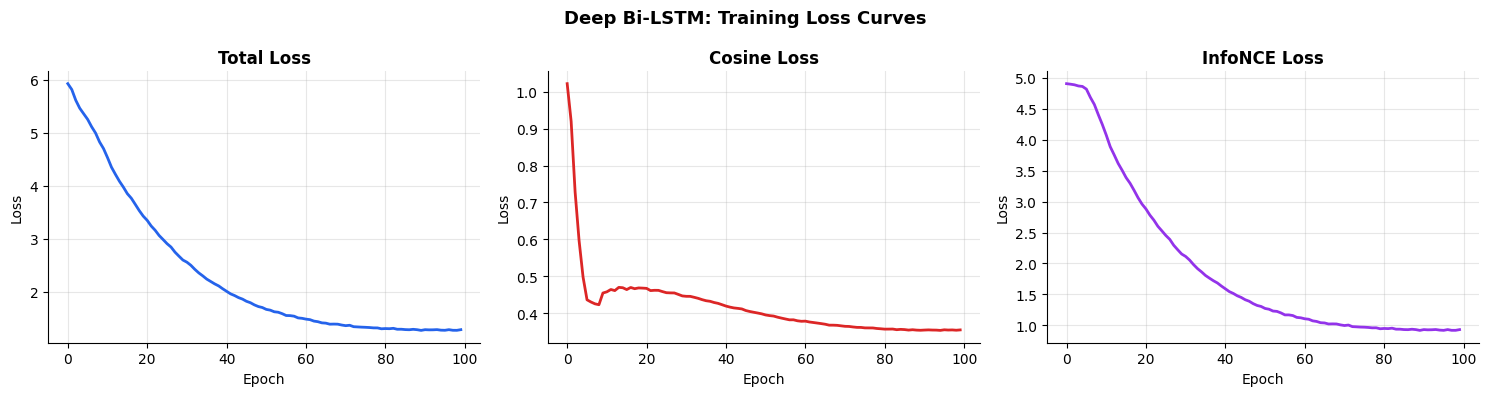

In [37]:
# Plot training loss curves (updated to 1x3 grid, removing redundant Smooth L1)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
labels = ['Total Loss', 'Cosine Loss', 'InfoNCE Loss']
keys = ['total', 'cos', 'nce']
colours = ['#2563EB', '#DC2626', '#9333EA']

for ax, label, key, color in zip(axes, labels, keys, colours):
    ax.plot(lstm_history[key], color=color, linewidth=2)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Deep Bi-LSTM: Training Loss Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'lstm_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

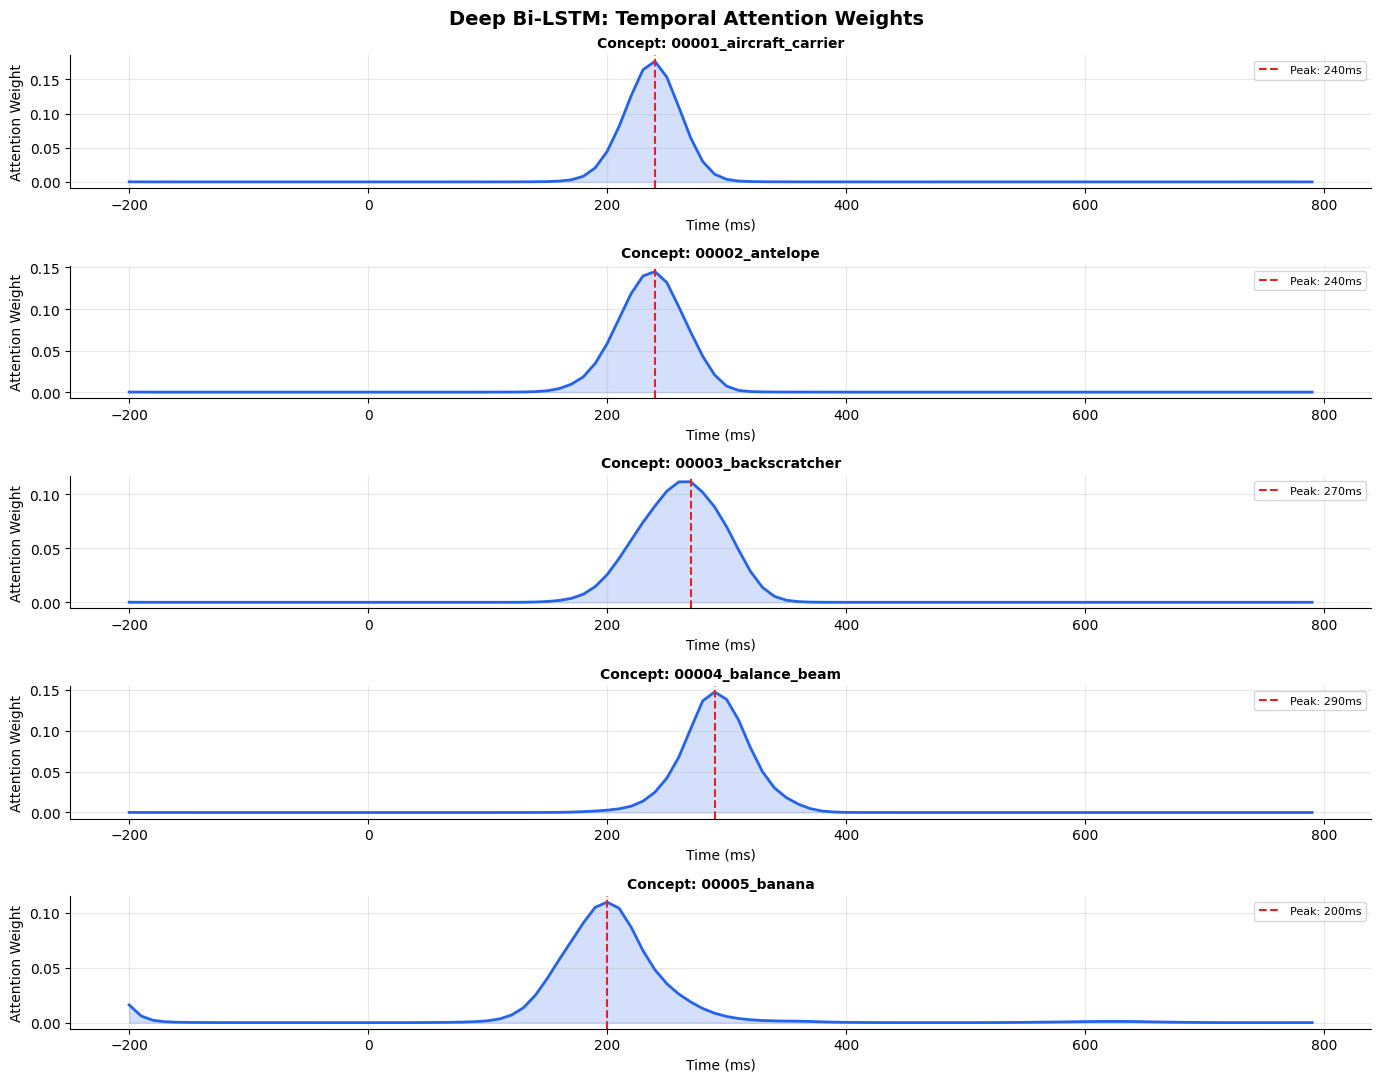

In [38]:
# Visualize Temporal Attention for the first 5 test concepts
time_ms = np.linspace(-200, 790, N_TIMEPOINTS)
n_show = 5

fig, axes = plt.subplots(n_show, 1, figsize=(14, n_show * 2.2))

for i in range(n_show):
    ax = axes[i]
    ax.plot(time_ms, lstm_attn[i], color='#2563EB', linewidth=2)
    ax.fill_between(time_ms, lstm_attn[i], alpha=0.2, color='#2563EB')
    
    peak_t = time_ms[np.argmax(lstm_attn[i])]
    ax.axvline(x=peak_t, color='#DC2626', linestyle='--', linewidth=1.5, label=f'Peak: {int(peak_t)}ms')
    
    ax.set_title(f'Concept: {test_concepts[i]}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Attention Weight')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Deep Bi-LSTM: Temporal Attention Weights', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'lstm_attention.png'), dpi=150, bbox_inches='tight')
plt.show()

# ── Temporal Patch Embedding
# Splits EEG time series into non-overlapping patches — same idea as ViT for images
# Each patch captures a 10ms window of activity across all 17 channels

class TemporalPatchEmbedding(nn.Module):
    def __init__(self, n_channels=17, patch_size=10, d_model=256):
        super().__init__()
        self.patch_size = patch_size
        patch_dim       = n_channels * patch_size   # 17 * 10 = 170
        self.proj       = nn.Sequential(
            nn.Linear(patch_dim, d_model),
            nn.LayerNorm(d_model)
        )

    def forward(self, x):
        # x: (B, 100, 17)
        B, T, C   = x.shape
        n_patches = T // self.patch_size
        x = x.reshape(B, n_patches, self.patch_size * C)   # (B, 10, 170)
        return self.proj(x)                                 # (B, 10, 256)

In [39]:
class TemporalPatchEmbedding(nn.Module):
    def __init__(self, n_channels=17, patch_size=10, d_model=256):
        super().__init__()
        self.patch_size = patch_size
        patch_dim = n_channels * patch_size  # 17 channels * 10 timepoints = 170
        
        self.proj = nn.Sequential(
            nn.Linear(patch_dim, d_model),
            nn.LayerNorm(d_model)
        )

    def forward(self, x):
        # x shape: (Batch, Timepoints, Channels) -> (B, 100, 17)
        B, T, C = x.shape
        n_patches = T // self.patch_size
        
        # Flatten the temporal patch across channels
        x = x.reshape(B, n_patches, self.patch_size * C)  
        
        return self.proj(x)

In [40]:
class LearnablePositionalEncoding(nn.Module):
    def __init__(self, n_patches, d_model):
        super().__init__()
        # 10 patches is short enough that a learnable embedding outperforms fixed sinusoidal
        self.pos_embed = nn.Parameter(torch.randn(1, n_patches, d_model) * 0.02)

    def forward(self, x):
        return x + self.pos_embed  # Broadcasts over batch

In [41]:
class TemporalTransformer(nn.Module):
    def __init__(self, n_channels=17, patch_size=10, n_patches=10,
                 d_model=256, n_heads=8, n_layers=4,
                 clip_dim=512, dropout=0.3):
        super().__init__()

        self.patch_embed = TemporalPatchEmbedding(n_channels, patch_size, d_model)
        self.pos_enc = LearnablePositionalEncoding(n_patches, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            activation='gelu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_model)

        self.output_proj = nn.Sequential(
            nn.Linear(d_model, clip_dim),
            nn.LayerNorm(clip_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(clip_dim, clip_dim)
        )

    def forward(self, x):
        # Defensive Check: Auto-correct if input arrives as (Batch, Channels, Timepoints)
        if x.shape[-1] != 17 and x.shape[1] == 17:
            x = x.transpose(1, 2)
            
        x = self.patch_embed(x)
        x = self.pos_enc(x)
        x = self.transformer(x)
        x = self.norm(x)

        # Global average pooling across the sequence of patches
        context = x.mean(dim=1)

        out = self.output_proj(context)
        out = F.normalize(out, dim=-1)  
        
        # Return uniform dummy weights to maintain API compatibility with the Bi-LSTM evaluate() function
        weights = torch.ones(x.shape[0], x.shape[1], device=x.device) / x.shape[1]
        
        return out, weights

In [42]:
PATCH_SIZE = 10
N_PATCHES = N_TIMEPOINTS // PATCH_SIZE

tr_model = TemporalTransformer(
    n_channels=N_CHANNELS,
    patch_size=PATCH_SIZE,
    n_patches=N_PATCHES,
    d_model=256,
    n_heads=8,
    n_layers=4,
    clip_dim=CLIP_DIM,
    dropout=DROPOUT
).to(DEVICE)

n_params_tr = sum(p.numel() for p in tr_model.parameters() if p.requires_grad)
print(f'Temporal Transformer loaded to {DEVICE} | Trainable Parameters: {n_params_tr:,}')

Temporal Transformer loaded to cpu | Trainable Parameters: 3,601,664


In [43]:
TR_CKPT = os.path.join(CKPT_DIR, 'transformer_best.pt')

print('=== Training Temporal Transformer ===')
tr_history = train_model(tr_model, train_loader, EPOCHS, LR, DEVICE, TR_CKPT)

=== Training Temporal Transformer ===
Epoch   1/100 | Loss: 5.9019 | Cos: 0.9796 | NCE: 4.9223 | LR: 0.000050 [Saved]
Epoch   5/100 | Loss: 5.2131 | Cos: 0.4232 | NCE: 4.7899 | LR: 0.000250 [Saved]
Epoch  10/100 | Loss: 4.4118 | Cos: 0.4270 | NCE: 3.9849 | LR: 0.000500 [Saved]
Epoch  15/100 | Loss: 3.7612 | Cos: 0.4389 | NCE: 3.3222 | LR: 0.000496 [Saved]
Epoch  20/100 | Loss: 3.2906 | Cos: 0.4449 | NCE: 2.8456 | LR: 0.000485 [Saved]
Epoch  25/100 | Loss: 2.8977 | Cos: 0.4435 | NCE: 2.4542 | LR: 0.000467 [Saved]
Epoch  30/100 | Loss: 2.5946 | Cos: 0.4343 | NCE: 2.1603 | LR: 0.000442 [Saved]
Epoch  35/100 | Loss: 2.3700 | Cos: 0.4283 | NCE: 1.9417 | LR: 0.000411 [Saved]
Epoch  40/100 | Loss: 2.1569 | Cos: 0.4178 | NCE: 1.7390 | LR: 0.000375 [Saved]
Epoch  45/100 | Loss: 2.0149 | Cos: 0.4091 | NCE: 1.6058 | LR: 0.000336 [Saved]
Epoch  50/100 | Loss: 1.8623 | Cos: 0.4003 | NCE: 1.4620 | LR: 0.000293 [Saved]
Epoch  55/100 | Loss: 1.7493 | Cos: 0.3903 | NCE: 1.3590 | LR: 0.000250 [Saved]
Ep

In [44]:
# Load best weights and evaluate
tr_model.load_state_dict(torch.load(TR_CKPT, map_location=DEVICE))
tr_acc, tr_preds, tr_attn = evaluate(tr_model, test_eeg, test_clip_embeds, DEVICE)

print('\nTemporal Transformer Retrieval Results:')
print(f'  Top-1:  {tr_acc[1]:.1f}%  (Random: {100/N_CONCEPTS_TEST:.1f}%)')
print(f'  Top-5:  {tr_acc[5]:.1f}%  (Random: {500/N_CONCEPTS_TEST:.1f}%)')
print(f'  Top-10: {tr_acc[10]:.1f}% (Random: {1000/N_CONCEPTS_TEST:.1f}%)')


Temporal Transformer Retrieval Results:
  Top-1:  19.0%  (Random: 0.5%)
  Top-5:  41.5%  (Random: 2.5%)
  Top-10: 56.0% (Random: 5.0%)


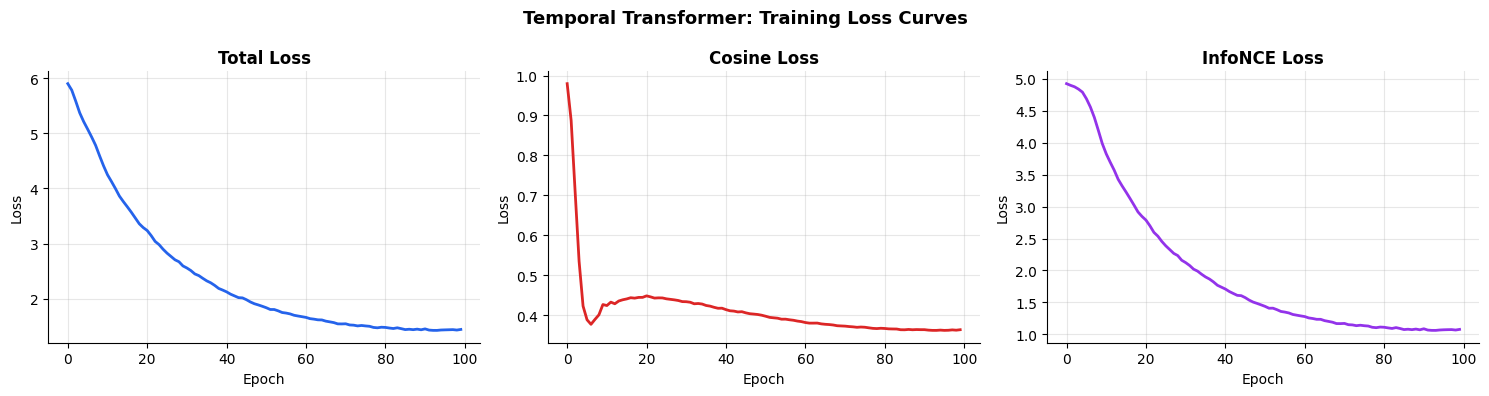

In [45]:
# Plot training loss curves (1x3 grid)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Note: labels, keys, and colours were previously defined in the Bi-LSTM plotting block
for ax, label, key, color in zip(axes, labels, keys, colours):
    ax.plot(tr_history[key], color=color, linewidth=2)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Temporal Transformer: Training Loss Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'transformer_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3. Model Comparison
Comparing the Top-K retrieval accuracy and parameter efficiency between the sequence-based Deep Bi-LSTM and the global-context Temporal Transformer.

In [46]:
# Random baseline probabilities (percentage)
random_1 = 100 / N_CONCEPTS_TEST
random_5 = 500 / N_CONCEPTS_TEST
random_10 = 1000 / N_CONCEPTS_TEST

print("Model Comparison: Top-K Retrieval Accuracy\n")
print(f"{'Metric':<12} | {'BiLSTM':<10} | {'Transformer':<12} | {'Random Baseline'}")
print("-" * 58)

for k, r in zip([1, 5, 10], [random_1, random_5, random_10]):
    lstm_val = lstm_acc[k]
    tr_val = tr_acc[k]
    winner = 'BiLSTM' if lstm_val > tr_val else 'Transformer'
    
    print(f"Top-{k:<8} | {lstm_val:>8.1f}% | {tr_val:>10.1f}% | {r:>14.1f}%  [{winner} wins]")

print("-" * 58)
print(f"{'Parameters':<12} | {n_params_lstm:>10,} | {n_params_tr:>12,} | -")

Model Comparison: Top-K Retrieval Accuracy

Metric       | BiLSTM     | Transformer  | Random Baseline
----------------------------------------------------------
Top-1        |     14.5% |       19.0% |            0.5%  [Transformer wins]
Top-5        |     39.5% |       41.5% |            2.5%  [Transformer wins]
Top-10       |     54.0% |       56.0% |            5.0%  [Transformer wins]
----------------------------------------------------------
Parameters   |  4,540,929 |    3,601,664 | -


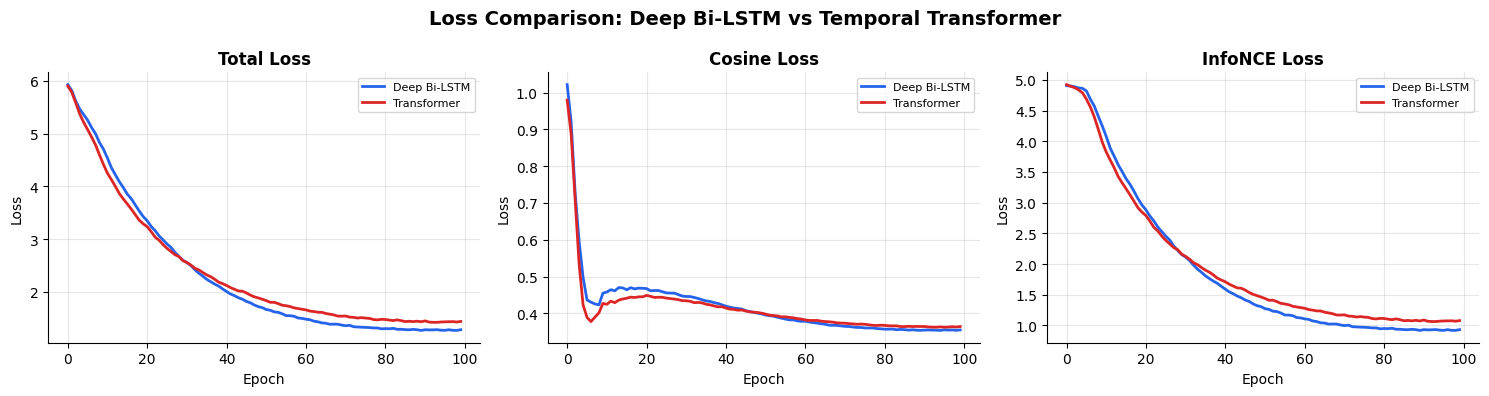

In [47]:
# Plot overlaid loss curves (1x3 grid)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, label, key in zip(axes, labels, keys):
    ax.plot(lstm_history[key], color='#2563EB', linewidth=2, label='Deep Bi-LSTM')
    ax.plot(tr_history[key], color='#DC2626', linewidth=2, label='Transformer')
    
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Loss Comparison: Deep Bi-LSTM vs Temporal Transformer', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'comparison_loss_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

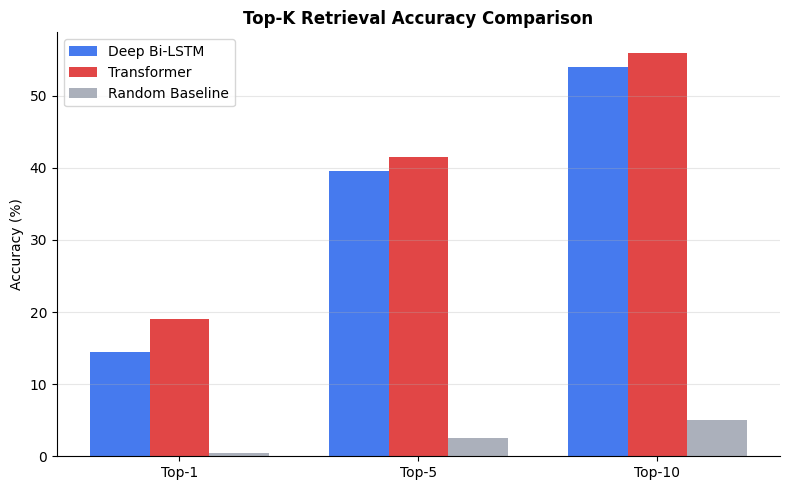

In [48]:
# Plot Top-K accuracy comparison
ks = [1, 5, 10]
x = np.arange(len(ks))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - width, [lstm_acc[k] for k in ks], width, label='Deep Bi-LSTM', color='#2563EB', alpha=0.85)
ax.bar(x, [tr_acc[k] for k in ks], width, label='Transformer', color='#DC2626', alpha=0.85)
ax.bar(x + width, [random_1, random_5, random_10], width, label='Random Baseline', color='#9CA3AF', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(['Top-1', 'Top-5', 'Top-10'])
ax.set_ylabel('Accuracy (%)')
ax.set_title('Top-K Retrieval Accuracy Comparison', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'comparison_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()

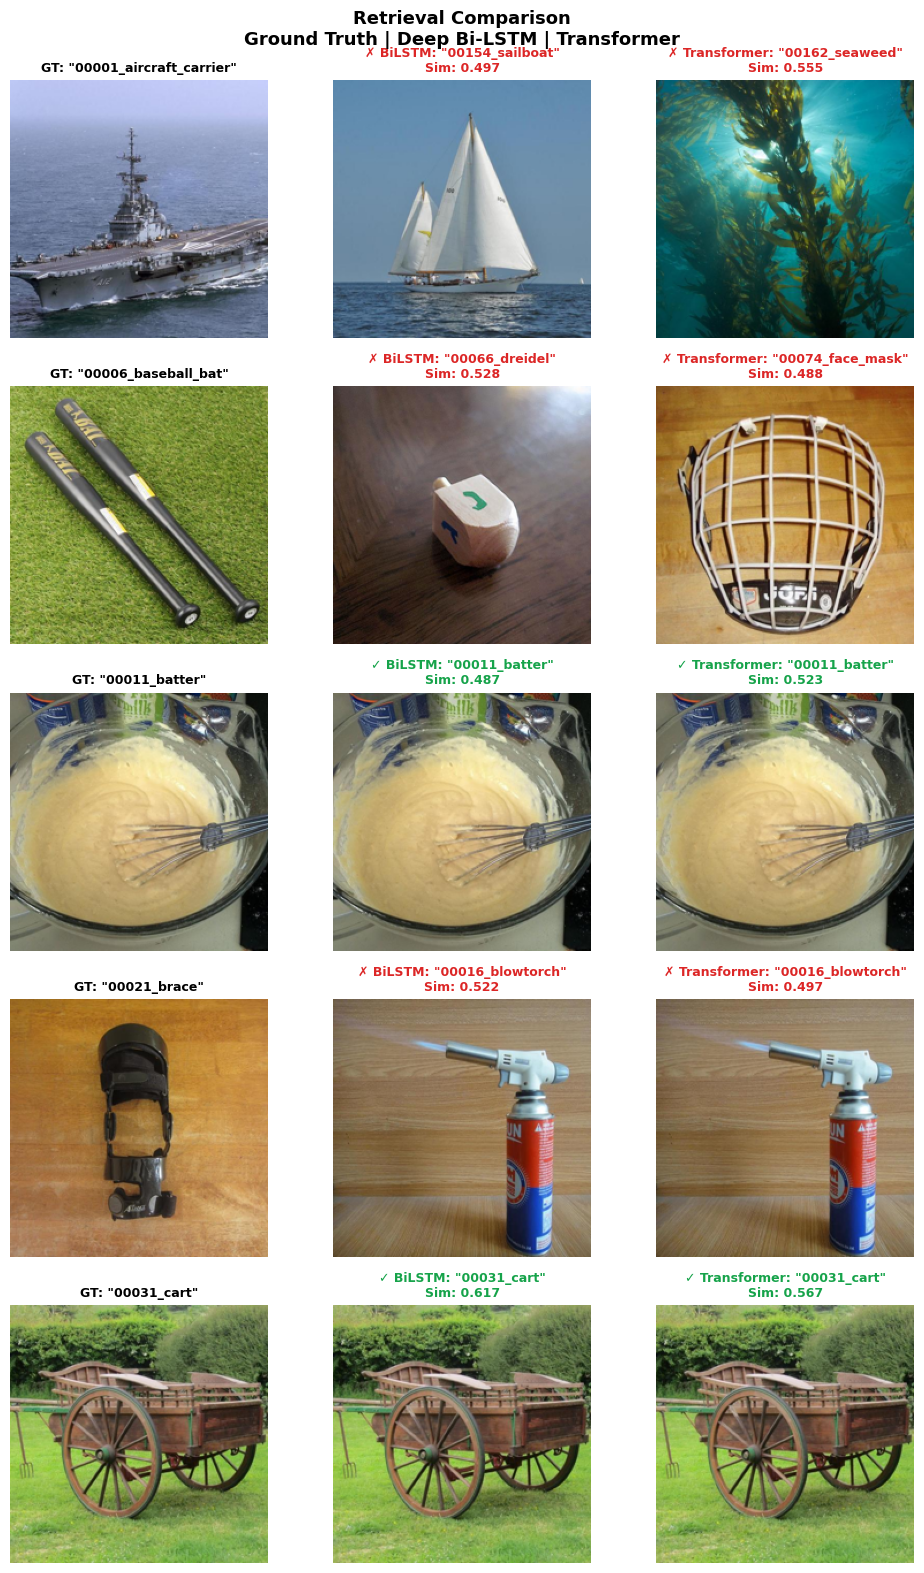

In [49]:
# Visualize Side-by-Side Retrieval: Ground Truth | Deep Bi-LSTM | Transformer
def retrieve_nearest(pred_embed, all_embeds, all_imgs):
    sims = cosine_similarity(pred_embed[np.newaxis], all_embeds)[0]
    idx = np.argmax(sims)
    return idx, sims[idx], all_imgs[idx][0]

DEMO = [0, 5, 10, 20, 30]
n = len(DEMO)

fig, axes = plt.subplots(n, 3, figsize=(10, n * 3.2))
fig.suptitle('Retrieval Comparison\nGround Truth | Deep Bi-LSTM | Transformer', fontsize=13, fontweight='bold')

for row, idx in enumerate(DEMO):
    concept = test_concepts[idx]

    # Ground Truth
    gt = Image.open(test_concept_imgs[idx][0]).convert('RGB').resize((224, 224))
    axes[row, 0].imshow(gt)
    axes[row, 0].set_title(f'GT: "{concept}"', fontsize=9, fontweight='bold')
    axes[row, 0].axis('off')

    # Bi-LSTM retrieval
    lstm_ret_idx, lstm_sim, lstm_path = retrieve_nearest(lstm_preds[idx], test_clip_embeds, test_concept_imgs)
    lstm_correct = (lstm_ret_idx == idx)
    axes[row, 1].imshow(Image.open(lstm_path).convert('RGB').resize((224, 224)))
    axes[row, 1].set_title(
        f'{"✓" if lstm_correct else "✗"} BiLSTM: "{test_concepts[lstm_ret_idx]}"\nSim: {lstm_sim:.3f}',
        fontsize=9, fontweight='bold',
        color='#16A34A' if lstm_correct else '#DC2626'
    )
    axes[row, 1].axis('off')

    # Transformer retrieval
    tr_ret_idx, tr_sim, tr_path = retrieve_nearest(tr_preds[idx], test_clip_embeds, test_concept_imgs)
    tr_correct = (tr_ret_idx == idx)
    axes[row, 2].imshow(Image.open(tr_path).convert('RGB').resize((224, 224)))
    axes[row, 2].set_title(
        f'{"✓" if tr_correct else "✗"} Transformer: "{test_concepts[tr_ret_idx]}"\nSim: {tr_sim:.3f}',
        fontsize=9, fontweight='bold',
        color='#16A34A' if tr_correct else '#DC2626'
    )
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'comparison_retrieval.png'), dpi=150, bbox_inches='tight')
plt.show()